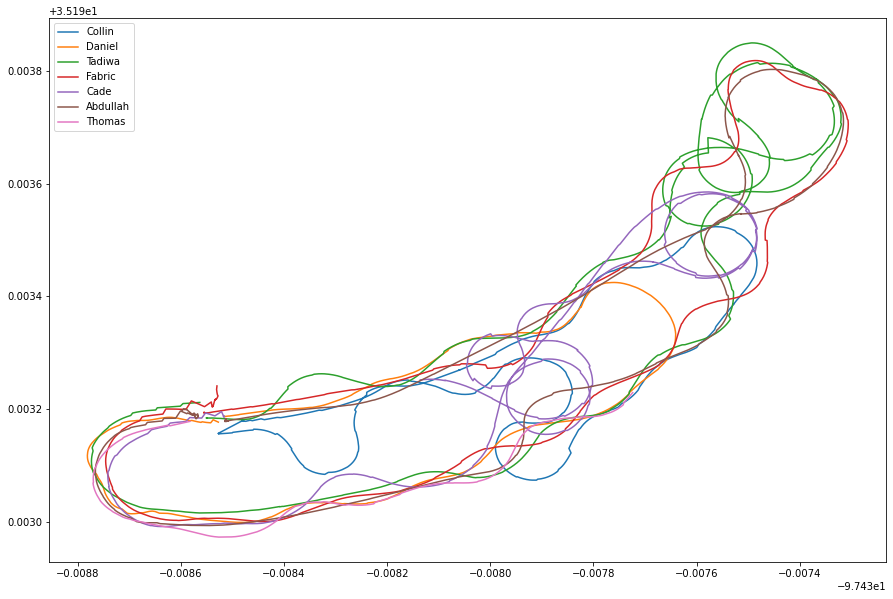

In [ ]:
## visualization
import pandas as pd
import matplotlib.pyplot as plt

a1 = pd.read_csv('C1_Collin.csv')
a2 = pd.read_csv('c2_Daniel.csv')
a3 = pd.read_csv('c3_Tadiwa.csv')
a4 = pd.read_csv('c4_Fabric.csv')
a5 = pd.read_csv('c5_Cade.csv')
a6 = pd.read_csv('c6_Abdullah.csv')
a7 = pd.read_csv('c7_Thomas.csv')

plt.figure(figsize=(15, 10))
plt.plot(a1['longitude'],a1['latitude'],label='Collin')
plt.plot(a2['longitude'],a2['latitude'],label='Daniel')
plt.plot(a3['longitude'],a3['latitude'],label='Tadiwa')
plt.plot(a4['longitude'],a4['latitude'],label='Fabric')
plt.plot(a5['longitude'],a5['latitude'],label='Cade')
plt.plot(a6['longitude'],a6['latitude'],label='Abdullah')
plt.plot(a7['longitude'],a7['latitude'],label='Thomas')
plt.legend()
plt.show()


Mean prediction error: 1.0906824338896977e-05 [W]


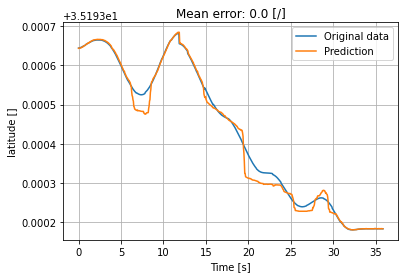

In [43]:
## Latitue - Data-driven model for vehicle dynamics 
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


## load data
data = pd.read_csv('c3_Tadiwa_revised.csv')

X_train = []
X_test  = []
Y_train = []
Y_test  = []

for i in range(0,1500):
    X_train.append([data['latitude_old'].iloc[i],data['longitude_old'].iloc[i],data['latitude'].iloc[i]-data['latitude_old'].iloc[0],data['longitude'].iloc[i],data['speed_mps'].iloc[i],data['steeringAngleDegree'].iloc[i]])
#     Y_train.append([data['latitude_future'].iloc[i],data['longitude_future'].iloc[i]])
    Y_train.append(data['latitude_future'].iloc[i])    
#     Y_train.append(data['longitude_future'].iloc[i]) 

for i in range(1500,len(data)-2):
    X_test.append([data['latitude_old'].iloc[i],data['longitude_old'].iloc[i],data['latitude'].iloc[i]-data['latitude_old'].iloc[0],data['longitude'].iloc[i],data['speed_mps'].iloc[i],data['steeringAngleDegree'].iloc[i]])
#     Y_test.append([data['latitude_future'].iloc[i],data['longitude_future'].iloc[i]])
    Y_test.append(data['latitude_future'].iloc[i])
#     Y_test.append(data['longitude_future'].iloc[i])

X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(Y_train)
y_test  = np.array(Y_test)

## Linear Regression
# reg = LinearRegression().fit(X_train, y_train)
# print(reg.score(X_train, y_train),reg.coef_,reg.intercept_)

## Decision Tree Regressor
# reg = DecisionTreeRegressor().fit(X_train, y_train)

## Random Forest
reg = RandomForestRegressor().fit(X_train, y_train)

## Neural Networks
# reg = MLPRegressor(random_state=1, max_iter=40000).fit(X_train, y_train)
# # reg.score(X_test, y_test)

## test prediction
y_pred = reg.predict(X_test)
    
y_error = np.mean(np.abs(y_pred - y_test))
print('Mean prediction error:',y_error,'[W]')

t = np.linspace(0,0.05*len(y_pred),len(y_pred))

## plot results
plt.plot(t,y_test)
plt.plot(t,y_pred)
plt.xlabel('Time [s]')
plt.ylabel('latitude []')
plt.legend(['Original data','Prediction'])
plt.title('Mean error: '+str(round(y_error/1e3,3))+' [/]')
# plt.xlim([40,100])
plt.grid()
plt.show()

y_pred_lat = y_pred
y_test_lat = y_test

Mean prediction error: 4.534204006878106e-05 [/]


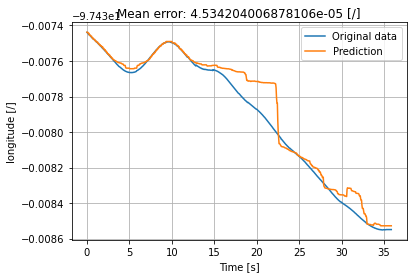

In [46]:
## Longitude - Data-driven model for vehicle dynamics 
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## load data
data = pd.read_csv('c3_Tadiwa_revised.csv')

X_train = []
X_test  = []
Y_train = []
Y_test  = []
for i in range(0,1500):
    X_train.append([data['latitude_old'].iloc[i],data['longitude_old'].iloc[i],data['latitude'].iloc[i],data['longitude'].iloc[i],data['speed_mps'].iloc[i],data['steeringAngleDegree'].iloc[i]])
#     Y_train.append(data['latitude_future'].iloc[i])
    Y_train.append(data['longitude_future'].iloc[i])    
for i in range(1500,len(data)-2):
    X_test.append([data['latitude_old'].iloc[i],data['longitude_old'].iloc[i],data['latitude'].iloc[i],data['longitude'].iloc[i],data['speed_mps'].iloc[i],data['steeringAngleDegree'].iloc[i]])
#     Y_test.append(data['latitude_future'].iloc[i])
    Y_test.append(data['longitude_future'].iloc[i])
X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(Y_train)
y_test  = np.array(Y_test)

## Linear Regression
# reg = LinearRegression().fit(X_train, y_train)
# print(reg.score(X_train, y_train),reg.coef_,reg.intercept_)

## Decision Tree Regressor
# reg = DecisionTreeRegressor().fit(X_train, y_train)

## Random Forest
reg = RandomForestRegressor().fit(X_train, y_train)

## Neural Networks
# reg = MLPRegressor(random_state=1, max_iter=40000).fit(X_train, y_train)
# # reg.score(X_test, y_test)

## test prediction
y_pred = reg.predict(X_test)

y_error = np.mean(np.abs(y_pred - y_test))
print('Mean prediction error:',y_error,'[/]')

t = np.linspace(0,0.05*len(y_pred),len(y_pred))

## plot results
plt.plot(t,y_test)
plt.plot(t,y_pred)
plt.xlabel('Time [s]')
plt.ylabel('longitude [/]')
plt.legend(['Original data','Prediction'])
plt.title('Mean error: '+str(y_error)+' [/]')
# plt.xlim([40,100])
plt.grid()
plt.show()

y_test_long = y_test
y_pred_long = y_pred

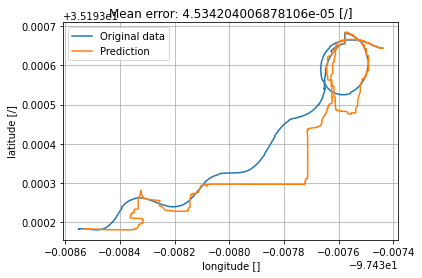

In [48]:
## plot latitude and longitude results together
plt.plot(y_test_long,y_test_lat)
plt.plot(y_pred_long,y_pred_lat)
plt.xlabel('longitude []')
plt.ylabel('latitude [/]')
plt.legend(['Original data','Prediction'])
plt.title('Mean error: '+str(y_error)+' [/]')
plt.grid()
plt.show()